### Student = David Medina Rosner

### Id = F11115117

## 1. Load K and RT parameters for camera 1 & 2

In [1]:
# libraries block
import re
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

In [2]:
# read .txt file that contains camera parameters
text = ''
with open('CameraParameter.txt', mode='r') as f:
    text = f.read() # read whole file as single string

text_list = text.split('\n\n')


# initialize parameters
cam1_K = []
cam1_RT = []
cam2_K = []
cam2_RT = []

for x in text_list:
    string_row = x.strip().split('\n')

    for y in string_row[1:]: # preprocess each row of string numbers into a list of numbers
        string_number_list = y.strip().split()
        
        if '[' in string_number_list:
            string_number_list.remove('[')
        elif ']' in string_number_list:
            string_number_list.remove(']')
        
        # create list of numbers
        number_list = [float(z) for z in string_number_list] 
        
        # add filtered row of numbers to the corresponding list
        if string_row[0] == 'Cam1_K':
            cam1_K.append(number_list)
        elif string_row[0] == 'Cam1_RT':
            cam1_RT.append(number_list)
        elif string_row[0] == 'Cam2_K':
            cam2_K.append(number_list)
        elif string_row[0] == 'Cam2_RT':
            cam2_RT.append(number_list)

In [3]:
# convert list of numbers into numpy arrays
cam1_K = np.array(cam1_K)
cam1_RT = np.array(cam1_RT)

cam2_K = np.array(cam2_K)
cam2_RT = np.array(cam2_RT)

In [4]:
cam1_K

array([[2.6666667e+03, 0.0000000e+00, 9.6000000e+02],
       [0.0000000e+00, 2.6666667e+03, 5.4000000e+02],
       [0.0000000e+00, 0.0000000e+00, 1.0000000e+00]])

In [5]:
cam1_RT

array([[ 9.8744490e-01, -1.5763340e-01, -1.0215400e-02,  1.1840861e+01],
       [-1.6543200e-02, -3.8882800e-02, -9.9910680e-01,  1.1459197e+00],
       [ 1.5709540e-01,  9.8673200e-01, -4.1002400e-02,  5.0106411e+01]])

In [6]:
cam2_K

array([[4.266667e+03, 0.000000e+00, 9.600000e+02],
       [0.000000e+00, 4.266667e+03, 5.400000e+02],
       [0.000000e+00, 0.000000e+00, 1.000000e+00]])

In [7]:
cam2_RT

array([[-4.0000000e-07, -1.0000000e+00,  1.0000000e-07,  1.2915463e+01],
       [-2.9936500e-01,  0.0000000e+00, -9.5413860e-01, -7.8007503e+00],
       [ 9.5413860e-01, -4.0000000e-07, -2.9936500e-01,  1.1606975e+02]])

## 2. Load world coordinates

In [8]:
# load world parameters
world_coordinates = np.loadtxt('3D_Trajectory.xyz')
world_coordinates

array([[-1.9815445e-02,  8.8474160e+00, -5.5514800e-01],
       [-4.1890144e-01,  8.8555620e+00, -4.6813402e-01],
       [-7.7710724e-01,  8.8647260e+00, -3.8862354e-01],
       ...,
       [-4.7639200e+01,  1.3879049e+01,  5.2835400e+00],
       [-4.7895573e+01,  1.3822389e+01,  5.1623554e+00],
       [-4.8180380e+01,  1.3758158e+01,  5.0257688e+00]])

In [9]:
# add a column of 1's to the world coordinates
row, col = world_coordinates.shape
array_ones = np.ones((row, 1))

coordinate_list = np.hstack((world_coordinates, array_ones))
coordinate_list

array([[-1.9815445e-02,  8.8474160e+00, -5.5514800e-01,  1.0000000e+00],
       [-4.1890144e-01,  8.8555620e+00, -4.6813402e-01,  1.0000000e+00],
       [-7.7710724e-01,  8.8647260e+00, -3.8862354e-01,  1.0000000e+00],
       ...,
       [-4.7639200e+01,  1.3879049e+01,  5.2835400e+00,  1.0000000e+00],
       [-4.7895573e+01,  1.3822389e+01,  5.1623554e+00,  1.0000000e+00],
       [-4.8180380e+01,  1.3758158e+01,  5.0257688e+00,  1.0000000e+00]])

In [10]:
# transpose each xyz coordinate of the list
x_3d = [] # list of transposed world coordinates 

for x in coordinate_list:
    coordinate = x[np.newaxis, :]
    x_3d.append(coordinate.T)

In [11]:
x_3d

[array([[-0.01981545],
        [ 8.847416  ],
        [-0.555148  ],
        [ 1.        ]]),
 array([[-0.41890144],
        [ 8.855562  ],
        [-0.46813402],
        [ 1.        ]]),
 array([[-0.77710724],
        [ 8.864726  ],
        [-0.38862354],
        [ 1.        ]]),
 array([[-1.0996742 ],
        [ 8.874774  ],
        [-0.31566554],
        [ 1.        ]]),
 array([[-1.3914337 ],
        [ 8.88558   ],
        [-0.24838413],
        [ 1.        ]]),
 array([[-1.6567917 ],
        [ 8.897034  ],
        [-0.18597822],
        [ 1.        ]]),
 array([[-1.8997478 ],
        [ 8.90903   ],
        [-0.12772194],
        [ 1.        ]]),
 array([[-2.1238823 ],
        [ 8.921479  ],
        [-0.07296425],
        [ 1.        ]]),
 array([[-2.3323689 ],
        [ 8.9342985 ],
        [-0.02112937],
        [ 1.        ]]),
 array([[-2.5279617 ],
        [ 8.947417  ],
        [ 0.02828357],
        [ 1.        ]]),
 array([[-2.713007  ],
        [ 8.960776  ],
        [ 0.07

## 3. Load images and perform matrix multiplication

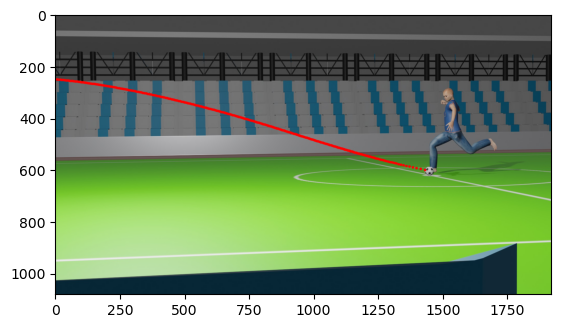

In [12]:
# load image from camera 1
img_1_bgr = cv.imread('SceneFromCamera1.jpg')
img_1 = cv.cvtColor(img_1_bgr, cv.COLOR_BGR2RGB)

x_2d = [] # list of 2d projection coordinates, in pixels

# circle parameters
radius = 5
color = (255, 0, 0) # RGB color
line_width = -1

# loop over the list of transposed world coordinates
for x in x_3d:
    x_2d = cam1_K @ cam1_RT @ x # matrix multiplication
    x_2d = x_2d[0:2] / x_2d[2]
    
    circle_center = (int(x_2d[0][0]), int(x_2d[1][0]))
    cv.circle(img_1, circle_center, radius, color, line_width) # draw 2d projection of 3d trajectory

# save image
img_1_save = cv.cvtColor(img_1, cv.COLOR_RGB2BGR)
cv.imwrite('F11115117_1.jpg', img_1_save)    

# show image with 2d projection
plt.imshow(img_1)
plt.show()

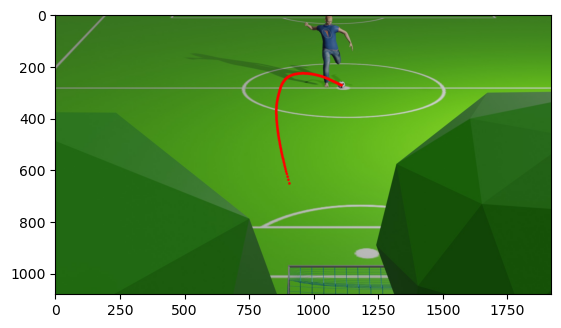

In [13]:
# load image from camera 2
img_2_bgr = cv.imread('SceneFromCamera2.jpg')
img_2 = cv.cvtColor(img_2_bgr, cv.COLOR_BGR2RGB)

x_2d = [] # list of 2d projection coordinates, in pixels

# circle parameters
radius = 5
color = (255, 0, 0) # RGB color
line_width = -1

# loop over the list of transposed world coordinates
for x in x_3d:
    x_2d = cam2_K @ cam2_RT @ x # matrix multiplication
    x_2d = x_2d[0:2] / x_2d[2]
    
    circle_center = (int(x_2d[0][0]), int(x_2d[1][0]))
    cv.circle(img_2, circle_center, radius, color, line_width) # draw 2d projection of 3d trajectory

# save image
img_2_save = cv.cvtColor(img_2, cv.COLOR_RGB2BGR)
cv.imwrite('F11115117_2.jpg', img_2_save)    

# show image with 2d projection
plt.imshow(img_2)
plt.show()